<a href="https://colab.research.google.com/github/xmessi08/ML-project-5/blob/main/ML_Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ROC-AUC: 0.9639
PR-AUC:  0.8782


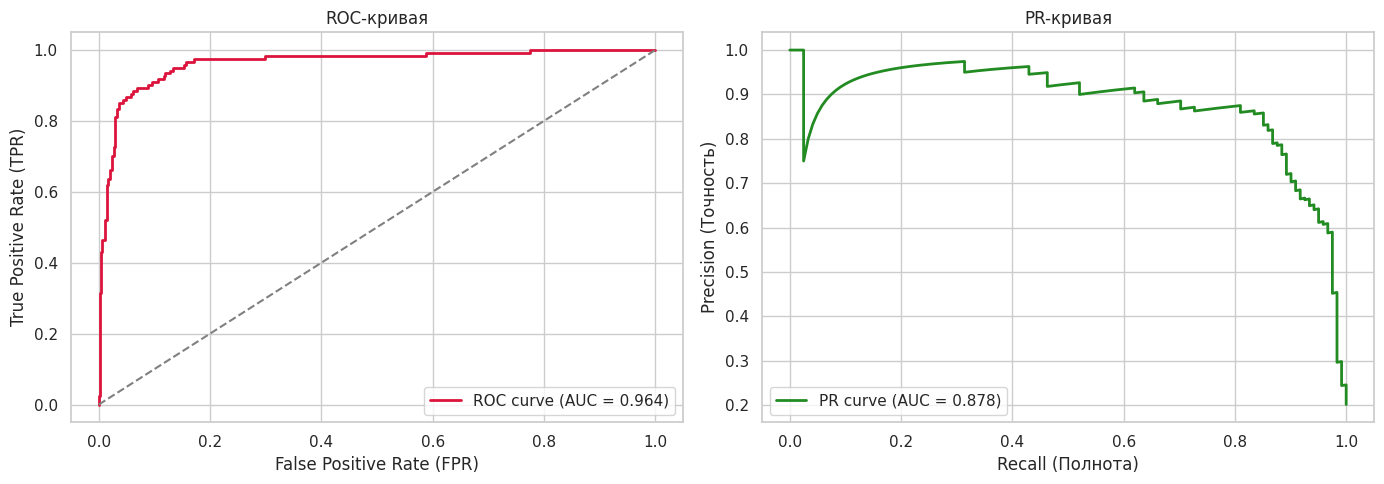

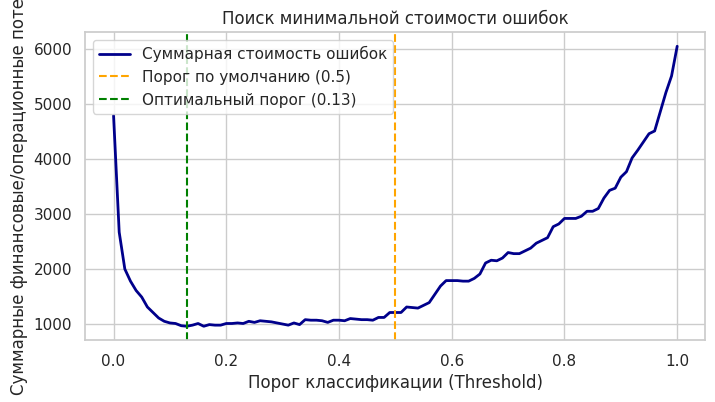

ПОРОГ: По умолчанию (T = 0.50)
Confusion Matrix: TN=463, FP=16, FN=21, TP=100
Количество FP ошибок: 16 (потери: 160)
Количество FN ошибок: 21 (потери: 1050)
ОБЩИЕ ПОТЕРИ: 1210

Отчет по классификации:
              precision    recall  f1-score   support

           0     0.9566    0.9666    0.9616       479
           1     0.8621    0.8264    0.8439       121

    accuracy                         0.9383       600
   macro avg     0.9093    0.8965    0.9027       600
weighted avg     0.9375    0.9383    0.9378       600

ПОРОГ: Оптимальный под цену ошибок (T = 0.13)
Confusion Matrix: TN=403, FP=76, FN=4, TP=117
Количество FP ошибок: 76 (потери: 760)
Количество FN ошибок: 4 (потери: 200)
ОБЩИЕ ПОТЕРИ: 960

Отчет по классификации:
              precision    recall  f1-score   support

           0     0.9902    0.8413    0.9097       479
           1     0.6062    0.9669    0.7452       121

    accuracy                         0.8667       600
   macro avg     0.7982    0.9041    0.827

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")

COST_FP = 10
COST_FN = 50

X, y = make_classification(
    n_samples=2000, n_classes=2, weights=[0.8, 0.2], random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC-кривая')
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].set_title('PR-кривая')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=300)
plt.show()

thresholds = np.linspace(0, 1, 101)
costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
min_cost = costs[best_idx]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, costs, color='darkblue', lw=2, label='Суммарная стоимость ошибок')
plt.axvline(0.5, color='orange', linestyle='--', label='Порог по умолчанию (0.5)')
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Оптимальный порог ({best_threshold:.2f})')
plt.xlabel('Порог классификации (Threshold)')
plt.ylabel('Суммарные финансовые/операционные потери')
plt.title('Поиск минимальной стоимости ошибок')
plt.legend()
plt.savefig('cost_vs_threshold.png', dpi=300)
plt.show()

def print_metrics(t, name):
    y_pred = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = (fp * COST_FP) + (fn * COST_FN)

    print("=" * 50)
    print(f"ПОРОГ: {name} (T = {t:.2f})")
    print("=" * 50)
    print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"Количество FP ошибок: {fp} (потери: {fp * COST_FP})")
    print(f"Количество FN ошибок: {fn} (потери: {fn * COST_FN})")
    print(f"ОБЩИЕ ПОТЕРИ: {cost}")
    print("\nОтчет по классификации:")
    print(classification_report(y_test, y_pred, digits=4))

print_metrics(0.5, "По умолчанию")
print_metrics(best_threshold, "Оптимальный под цену ошибок")